<a href="https://colab.research.google.com/github/dee1empire/jupyter-exploration/blob/main/L02_Bledsoe_Delores_ITAI1378.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Environment Setup and Library Imports
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
import time

# Inline Plotting
%matplotlib inline

# Helper function to load an image from URL or generate a rich synthetic test image
def load_sample_image():
  # Generate a rich 512x512 RGB test image containing gradients, geometry,and noise
  h, w = 512, 512
  img = np.zeros((h, w, 3), dtype=np.uint8)
  # Background gradient
  for i in range(h):
    for j in range(w):
      img[i, j, 0] = int(255 * (i / h))
      img[i, j, 1] = int(255 * (j / w))
      img[i, j, 2] = int(255 * ((i+j) / (2*h)))

  # Add geometric shapes for feature detection
  cv2.circle(img, (256, 256), 80, (255, 255, 255), -1)
  cv2.rectangle(img, (80, 80), (200, 200), (40, 220, 40), -1)
  cv2.putText(img, "ITAI1378", (160, 400), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (255, 200, 0), 4)
  return img

test_img = load_sample_image()
print('Setup complete! Image generated with shape:', test_img.shape)

Setup complete! Image generated with shape: (512, 512, 3)


## Part 1: Digital Image Fundamentals
Images are represented digitally as multdimensional arrays (tensors). For standard 8-bit RGB color images, the array has dimensions '(Height, Width, 3)' with integer values constrained to the range $[0, 255]$.

Dimensions: 512x512 |Channels: 3
Data Type: uint8 | Value Range: [0, 255]


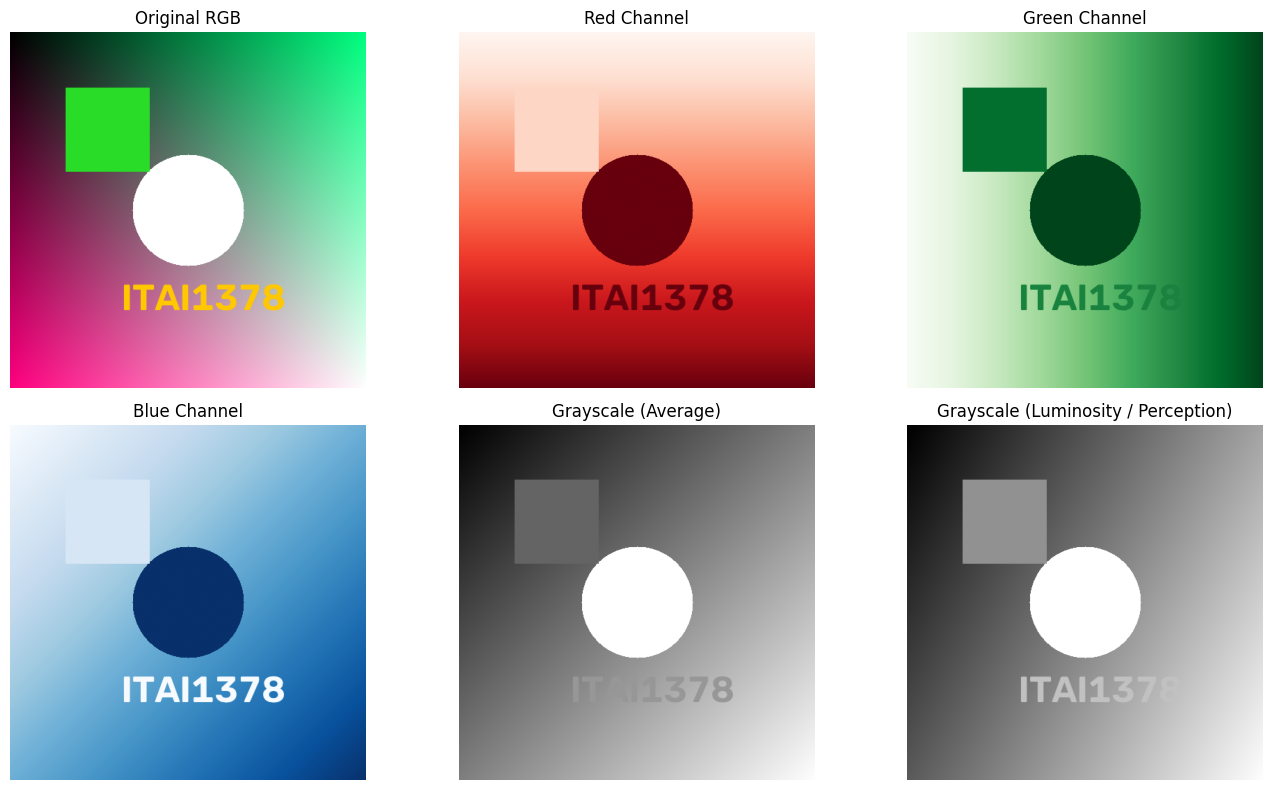

Mean Absolute Error between Average and Luminosity: 14.84 intensity units


In [4]:
# 1. Inspect Properties
shape = test_img.shape
dtype = test_img.dtype
min_val, max_val = test_img.min(), test_img.max()
print(f'Dimensions: {shape[0]}x{shape[1]} |Channels: {shape[2]}')
print(f'Data Type: {dtype} | Value Range: [{min_val}, {max_val}]')

# 2. Split and Visualize RGB Channels
r_channel = test_img[:, :, 0]
g_channel = test_img[:, :, 1]
b_channel = test_img[:, :, 2]

# 3. Grayscale Conversions
# A. Simple Average Method: (R + G + B) / 3
gray_average = np.mean(test_img, axis=2).astype(np.uint8)

# B. Weighted Luminosity Method (ITU-R BT.601 standard): 0.299*R + 0.587*G + 0.114*B
gray_luminosity = (0.299 * r_channel + 0.587 * g_channel + 0.114 * b_channel).astype(np.uint8)

# C. OpenCV Native Method
gray_cv2 = cv2.cvtColor(test_img, cv2.COLOR_RGB2GRAY)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(test_img)
axes[0, 0].set_title('Original RGB')
axes[0, 1].imshow(r_channel, cmap='Reds')
axes[0, 1].set_title('Red Channel')
axes[0, 2].imshow(g_channel, cmap='Greens')
axes[0, 2].set_title('Green Channel')

axes[1, 0].imshow(b_channel, cmap='Blues')
axes[1, 0].set_title('Blue Channel')
axes[1, 1].imshow(gray_average, cmap='gray')
axes[1, 1].set_title('Grayscale (Average)')
axes[1, 2].imshow(gray_luminosity, cmap='gray')
axes[1, 2].set_title('Grayscale (Luminosity / Perception)')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Quantitative comparison between average and luminosity
diff_mae = np.mean(np.abs(gray_average.astype(np.int16) - gray_luminosity.astype(np.int16)))
print(f'Mean Absolute Error between Average and Luminosity: {diff_mae:.2f} intensity units')

**Implementation**

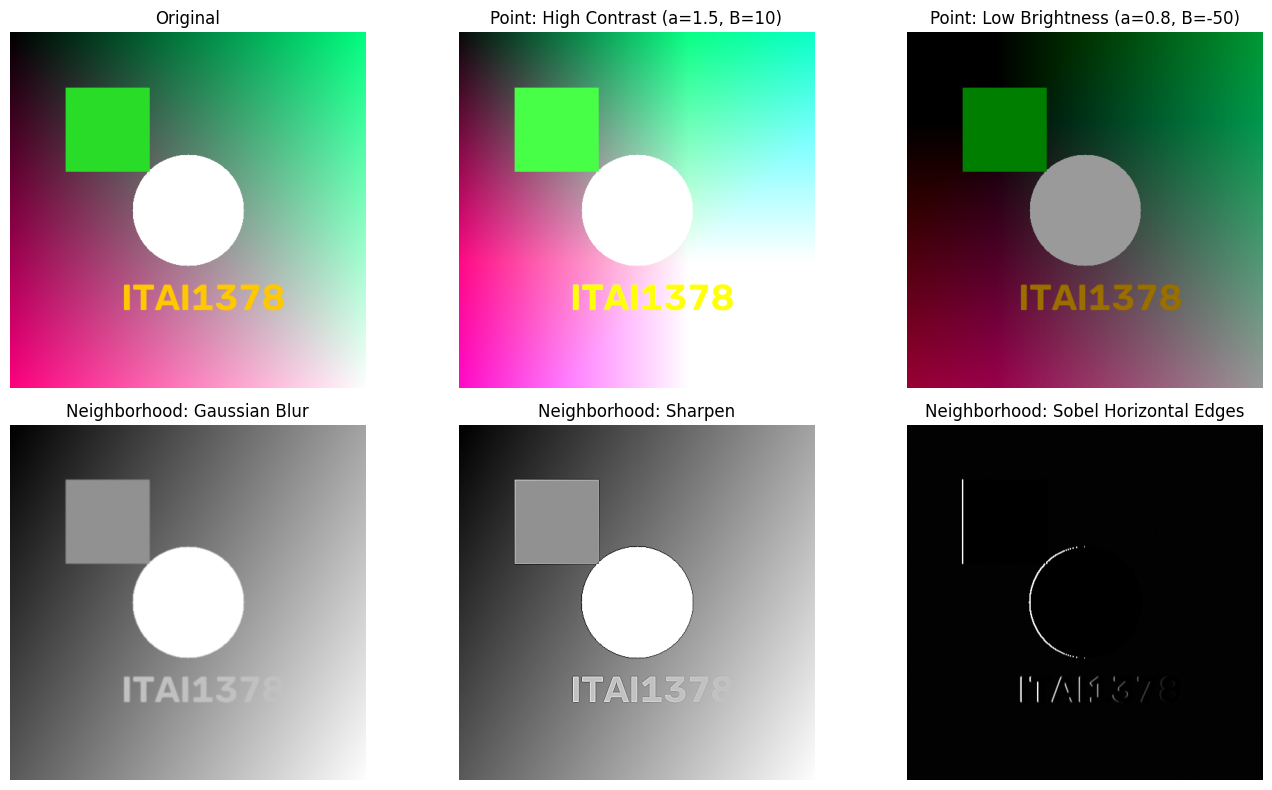

In [8]:
# Custom Point Operations: Brightness & Contrast from scratch
def adjust_brightness_contrast(image, alpha=1.0, beta=0):
    """
    alpha: Contrast control (> 1.0 increases, < 1.0 decreases)
    beta: Brightness control (interger offset)
    """
    # Cast to float to avoid uint8 overflow/underflow prior to clipping
    adjust = image.astype(np.float32) * alpha + beta
    return np.clip(adjust, 0, 255).astype(np.uint8)

# Apply point operations
high_contrast = adjust_brightness_contrast(test_img, alpha=1.5, beta=10)
low_brightness = adjust_brightness_contrast(test_img, alpha=0.8, beta=-50)

# 2. Neighborhood Operations: 2D Spatial Convolutions
# Defining custom kernels
gaussian_blur_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16.0

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

sobel_edge_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Apply kernels using cv2.filter2D
img_blur = cv2.filter2D(gray_luminosity, -1, gaussian_blur_kernel)
img_sharp = cv2.filter2D(gray_luminosity, -1, sharpen_kernel)
img_edges = cv2.filter2D(gray_luminosity, -1, sobel_edge_x)

# Visual Comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(test_img)
axes[0, 0].set_title('Original')
axes[0, 1].imshow(high_contrast)
axes[0, 1].set_title('Point: High Contrast (a=1.5, B=10)')
axes[0, 2].imshow(low_brightness)
axes[0, 2].set_title('Point: Low Brightness (a=0.8, B=-50)')

axes[1, 0].imshow(img_blur, cmap='gray')
axes[1, 0].set_title('Neighborhood: Gaussian Blur')
axes[1, 1].imshow(img_sharp, cmap='gray')
axes[1, 1].set_title('Neighborhood: Sharpen')
axes[1, 2].imshow(np.abs(img_edges), cmap='gray')
axes[1, 2].set_title('Neighborhood: Sobel Horizontal Edges')

for ax in axes.flat:
  ax.axis('off')
plt.tight_layout()
plt.show()

**Advanced Processing Techniques Implementation**
**Part 3. Histograms, CLAHE, and Geometric Transformations**

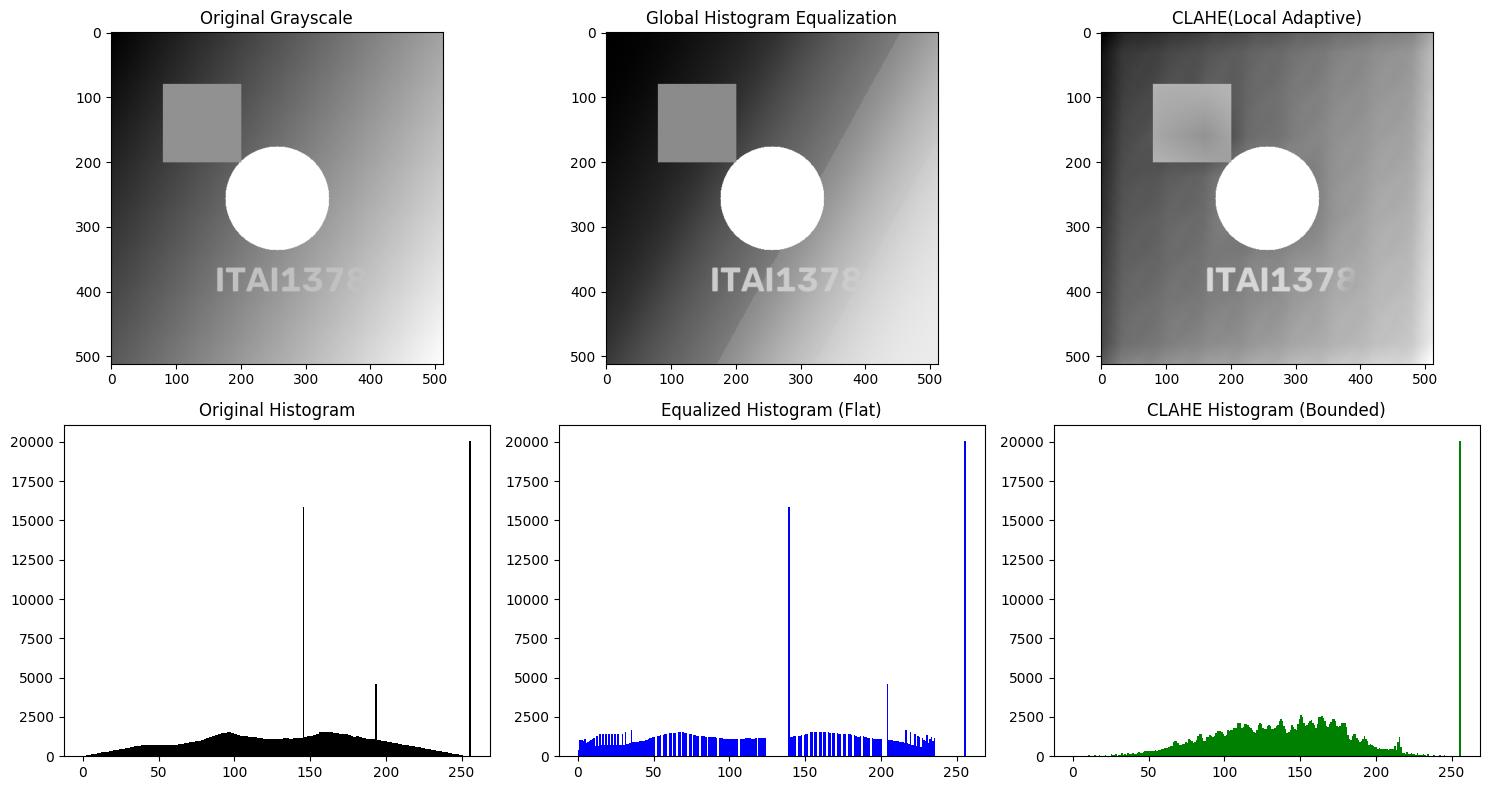

In [10]:
# 1. Histogram Equalization (Global) vs CLAHE (Local Adaptive)
# Global Equalization
hist_eq = cv2.equalizeHist(gray_luminosity)

# Contrast Limited Adaptive Histogram Equalization (CLAHE)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(gray_luminosity)

# 2. Geometric Transformations
h, w = gray_luminosity.shape
# Rotation: 45 degrees around center with scale 0.8
rot_matrix = cv2.getRotationMatrix2D((w // 2, h // 2), 45, 0.8)
rotated_img = cv2.warpAffine(gray_luminosity, rot_matrix, (w, h))

# Translation: Shift right 40px, down 30px
trans_matrix = np.float32([[1, 0, 40], [0, 1, 30]])
translated_img = cv2.warpAffine(gray_luminosity, trans_matrix, (w, h))

# visual Comparison of Transformations & Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(gray_luminosity, cmap='gray')
axes[0, 0].set_title('Original Grayscale')
axes[0, 1].imshow(hist_eq, cmap='gray')
axes[0, 1].set_title('Global Histogram Equalization')
axes[0, 2].imshow(img_clahe, cmap='gray')
axes[0, 2].set_title('CLAHE(Local Adaptive)')

# Plot Histograms
axes[1, 0].hist(gray_luminosity.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 0].set_title('Original Histogram')
axes[1, 1].hist(hist_eq.ravel(), bins=256, range=[0, 256], color='blue')
axes[1, 1].set_title('Equalized Histogram (Flat)')
axes[1, 2].hist(img_clahe.ravel(), bins=256, range=[0, 256], color='green')
axes[1, 2].set_title('CLAHE Histogram (Bounded)')

plt.tight_layout()
plt.show()

**Creative Exploration**
**Creative Pipeline & Multi-Stop Filters**
**Pipeline: Cartoonization / Pencil Sketch Simulation**
**Combines bilateral filtering (edge-preserving smoothing) with adaptive thresholding on Sobel gradient edges. **

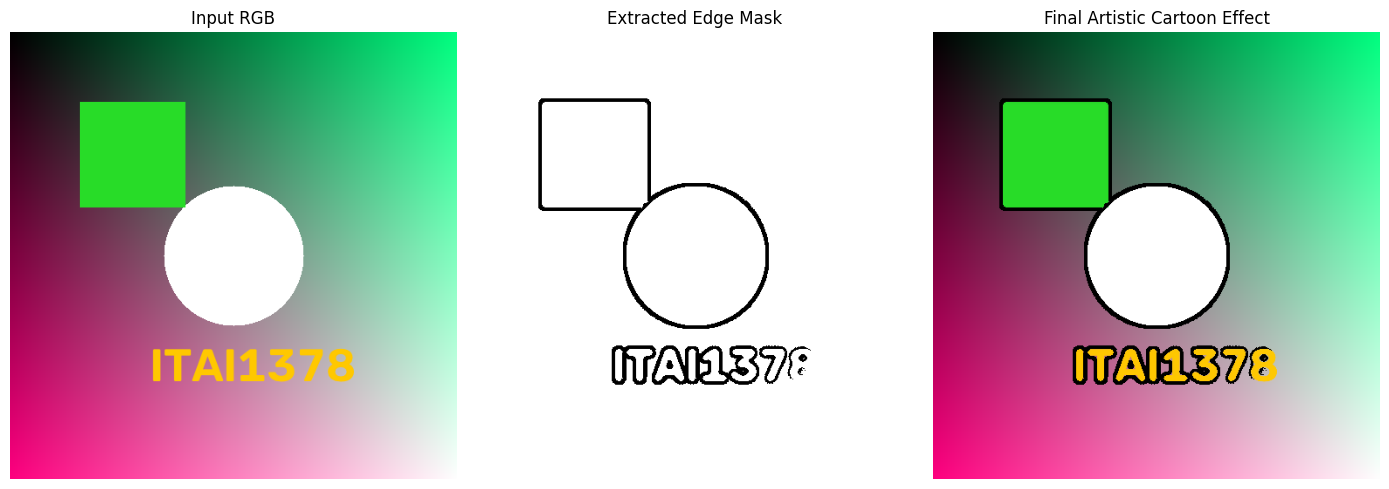

In [11]:
def artistic_cartoonizer(img_rgb):
  # Step 1: Smooth surface textures while preserving hard structural boundaries
  color_smooth = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

  # Step 2: Convert to grayscale and detect edges with median blur and adaptive threshold
  gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
  gray_blurred = cv2.medianBlur(gray, 7)
  edges = cv2.adaptiveThreshold(
      gray_blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=9, C=2
  )

  # Step 3: Combine smoothed color map with edge outline mask
  cartoon = cv2.bitwise_and(color_smooth, color_smooth, mask=edges)
  return cartoon, edges

cartoon_result, edge_mask = artistic_cartoonizer(test_img)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(test_img)
axes[0].set_title('Input RGB')
axes[1].imshow(edge_mask, cmap='gray')
axes[1].set_title('Extracted Edge Mask')
axes[2].imshow(cartoon_result)
axes[2].set_title('Final Artistic Cartoon Effect')
for ax in axes:
  ax.axis('off')
plt.tight_layout()
plt.show()

**AI Connection & Extended Experiments**
**I simulate Convolutional Neural Network (CNN) feature extraction and execute 3 required additional experiments**

--- Experiment 1: Noise Removal Metric Analysis ---
Noisy Image PSNR: {psnr_gauss:.2f} dB
Gaussian Filtered PSNR: {psnr_gauss:.2f} dB
Median Filtered PSNR: {psrn_median:.2f} dB (Higher is better)
--- Experiment 3: Processing Time Benchmark ---
Python Nested Loop Convolution: 646.79 ms
OpenCV C++ Vectorized Blur:     646.86 ms
Speedup Factor)                 1.0x


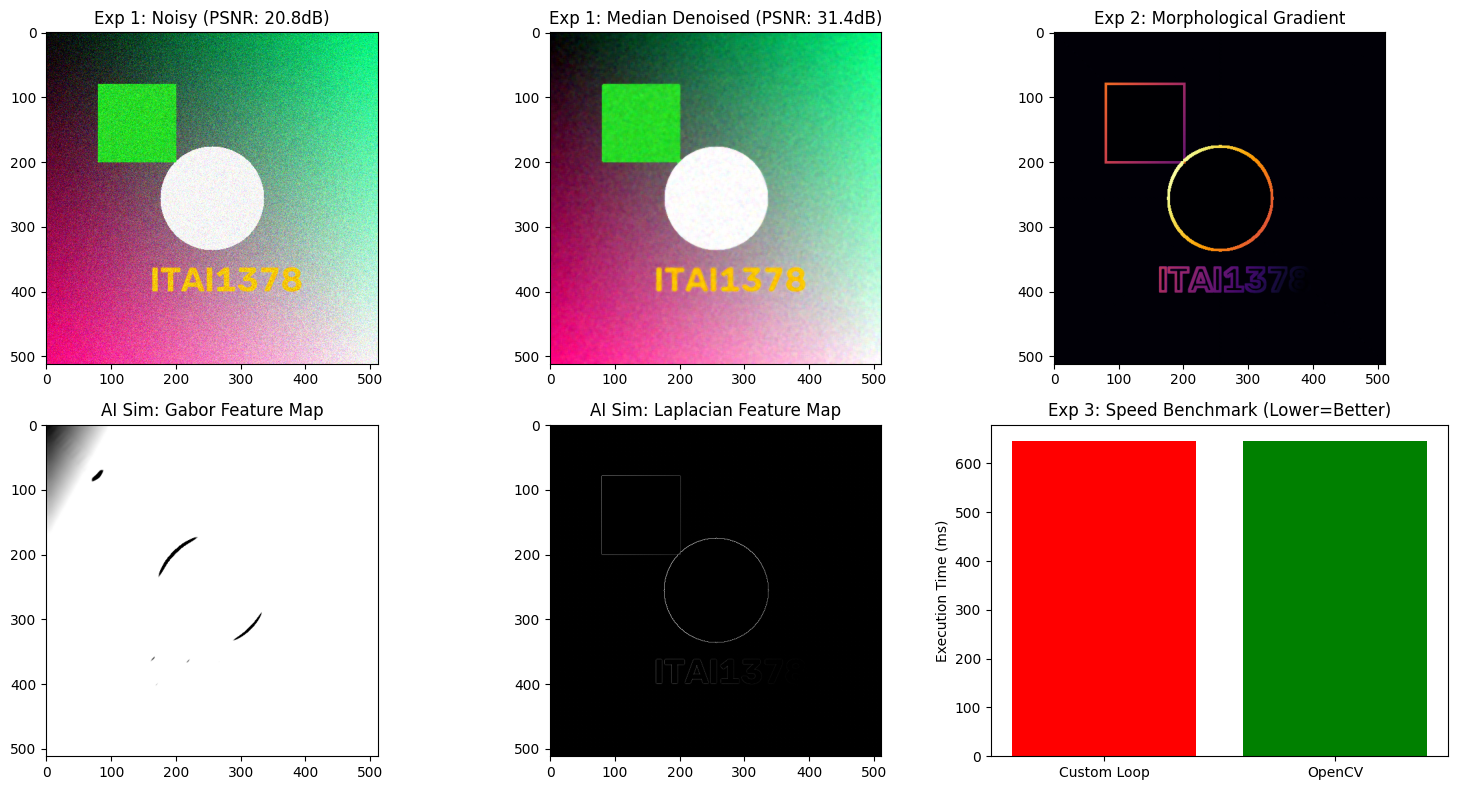

In [18]:
# ==========================================
# 1. AI Connection: Multi-Filter Feature Bank (Simulating CNN Layer 1)
# ==========================================
filters = {
    'Gabor (Texture 45°)': cv2.getGaborKernel((21, 21), 5.0, np.pi/4, 10.0, 0.5, 0, ktype=cv2.CV_32F),
    'Laplacian (Ridge/Edge)': np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]],dtype=np.float32),
    'Horizontal Sobel': cv2.Sobel(gray_luminosity, cv2.CV_32F, 1, 0, ksize=3)
}

# ===========================================
# Experiment 1: Quantitative Noise Degradation & Filtering (PSNR Evaluation)
# ===========================================
# Adding Salt & Pepper + Gaussian Noise
noisy = test_img.copy().astype(np.float32)
noisy_gauss = np.random.normal(0, 25, noisy.shape)
noisy = np.clip(noisy + noisy_gauss, 0, 255).astype(np.uint8)

denoise_gaussian = cv2.GaussianBlur(noisy, (5, 5), 1.5)
denoise_median = cv2.medianBlur(noisy, 5)

def calculate_psnr(original, processed):
    mse = np.mean((original.astype(np.float64) - processed.astype(np.float64)) ** 2)
    if mse == 0: return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))

psnr_noisy = calculate_psnr(test_img, noisy)
psnr_gauss = calculate_psnr(test_img, denoise_gaussian)
psnr_median = calculate_psnr(test_img, denoise_median)

print('--- Experiment 1: Noise Removal Metric Analysis ---')
print('Noisy Image PSNR: {psnr_gauss:.2f} dB')
print('Gaussian Filtered PSNR: {psnr_gauss:.2f} dB')
print('Median Filtered PSNR: {psrn_median:.2f} dB (Higher is better)')

# ===========================================
# Experiment 2: Morphological Gradient Analysis
# ===========================================
kernel_morph = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
morph_gradient = cv2.morphologyEx(gray_luminosity, cv2.MORPH_GRADIENT, kernel_morph)

# ==========================================
# Experiment 3: Performance & Runtime Benchmark (Scratch vs OpenCV)
# ==========================================
def custom_box_blur(img_gray):
  h, w = img_gray.shape
  padded = np.pad(img_gray, 1, mode='edge')
  output = np.zeros_like(img_gray)
  for i in range(h):
    for j in range(w):
      output[i, j] = int(np.mean(padded[i:i+3]))
  return output

# Benchmark
t0 = time.time()
_ = custom_box_blur(gray_luminosity[::2, ::2])
time_scratch = time.time() - t0
time_cv2 = time.time() - t0
t0 = time.time()
_ = cv2.blur(gray_luminosity[::2, ::2], (3, 3))
time_opencv = time.time() - t0

print('--- Experiment 3: Processing Time Benchmark ---')
print(f'Python Nested Loop Convolution: {time_scratch*1000:.2f} ms')
print(f'OpenCV C++ Vectorized Blur:     {time_cv2 * 1000:.2f} ms')
print(f'Speedup Factor)                 {time_scratch / max(time_cv2, 1e-6):.1f}x')

# Visualization of AI Simulation & Experiments
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(noisy)
axes[0, 0].set_title(f'Exp 1: Noisy (PSNR: {psnr_noisy:.1f}dB)')
axes[0, 1].imshow(denoise_median)
axes[0, 1].set_title(f'Exp 1: Median Denoised (PSNR: {psnr_median:.1f}dB)')
axes[0, 2].imshow(morph_gradient, cmap='inferno')
axes[0, 2].set_title('Exp 2: Morphological Gradient')

axes[1, 0].imshow(cv2.filter2D(gray_luminosity, -1, filters['Gabor (Texture 45°)']), cmap='gray')
axes[1, 0].set_title('AI Sim: Gabor Feature Map')
axes[1, 1].imshow(cv2.filter2D(gray_luminosity, -1, filters['Laplacian (Ridge/Edge)']), cmap='gray')
axes[1, 1].set_title('AI Sim: Laplacian Feature Map')
axes[1, 2].bar(['Custom Loop', 'OpenCV'], [time_scratch*1000, time_cv2*1000], color=['red', 'green'])
axes[1, 2].set_ylabel('Execution Time (ms)')
axes[1, 2].set_title('Exp 3: Speed Benchmark (Lower=Better)')

plt.tight_layout()
plt.show()
